# Keeping relevant labels from extended atlas

Since the extended atlas has 82 labels, we don't want to use all of them (most won't be relevant for our analysis). <br>
However, some are relevant.<br>
Here, we mainly keep the original annotations, but additionally use some of the extended atlas labels for relevant cell-types.



In [1]:
suppressPackageStartupMessages({
    library(dplyr)
    library(data.table)
    library(ggplot2)
})

here::i_am("mapping/analysis/01_Combine_atlas_labels.ipynb")

# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

set.seed(1234)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/12_Eomes_T_Mixl1/T_E75/code



In [2]:
meta = fread(paste0(io$basedir,"/results/rna/mapping/manual/sample_metadata_after_mapping.txt.gz"))

In [3]:
compare = data.table(cell = meta$cell, original = meta$celltype.mapped_mnn, extended = meta$celltype_extended.mapped_mnn) %>%
    .[,count := .N, by=c('original', 'extended')] %>%
    .[,tot := .N, by='original'] %>% .[,prop := count/tot] %>%
    unique(by=c('original', 'extended')) 

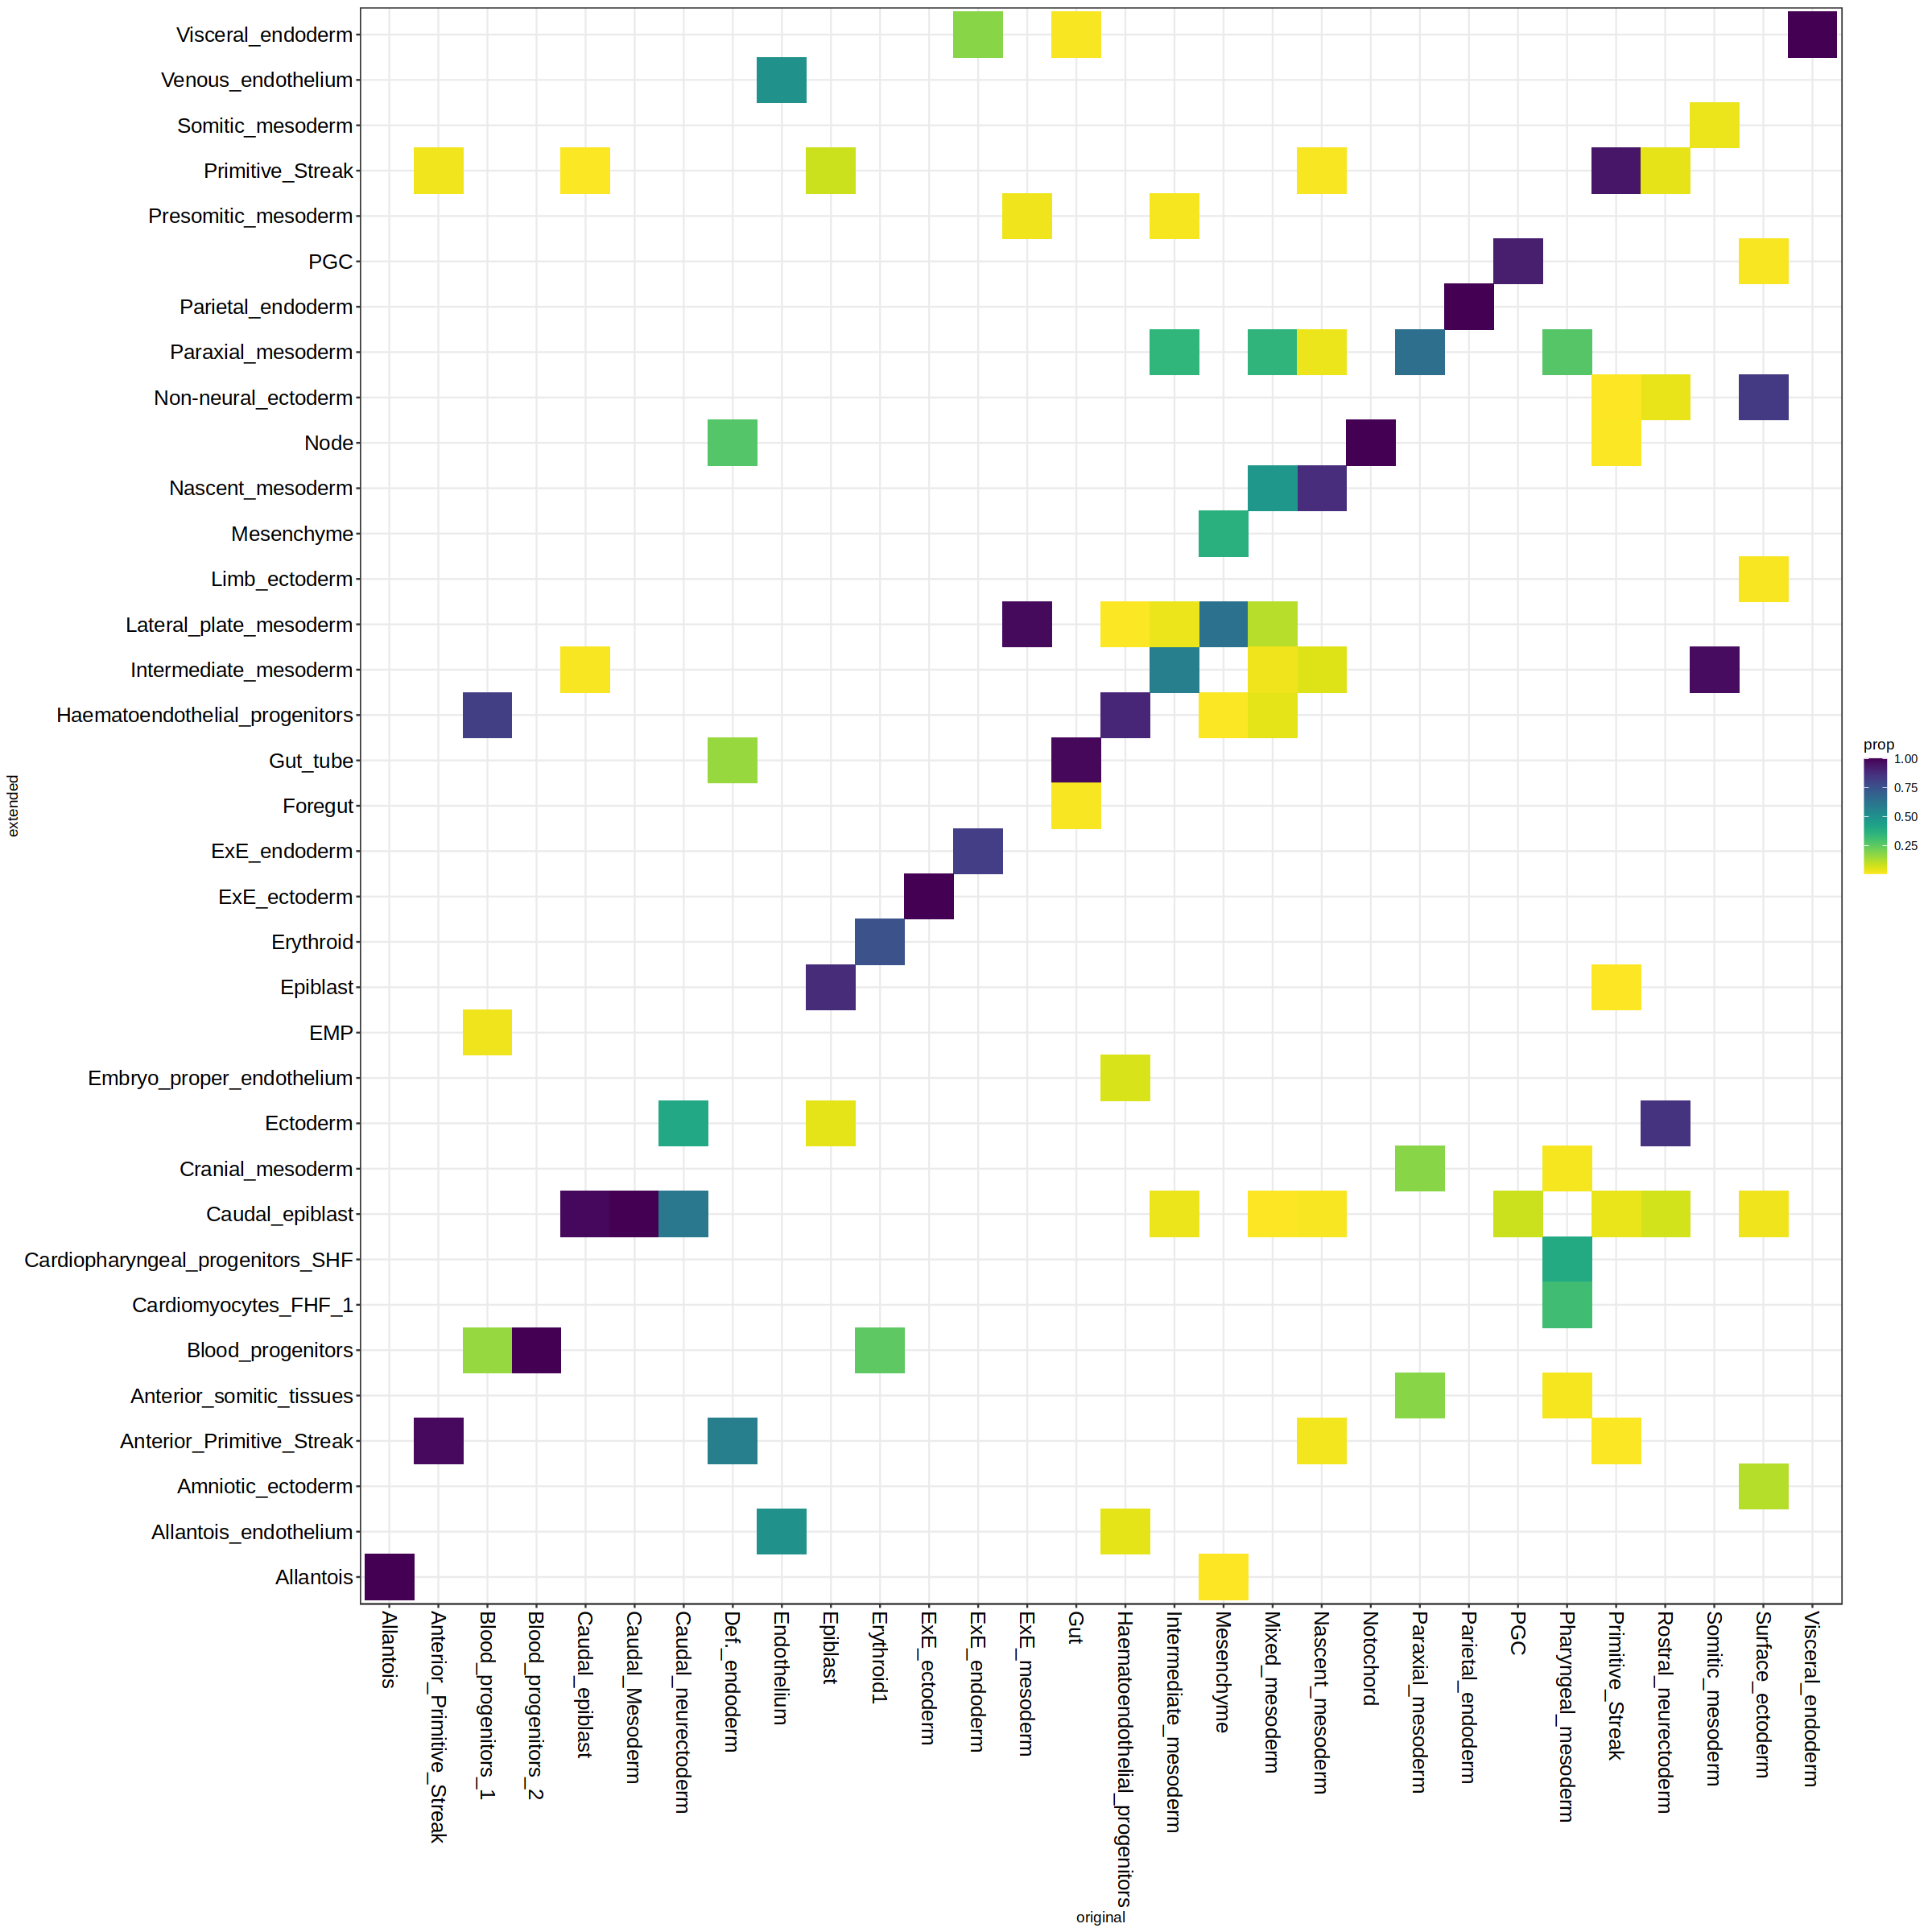

In [4]:
options(repr.plot.width=20, repr.plot.height=20)
ggplot(compare[!is.na(original)], aes(original, extended, fill=prop)) + 
    geom_tile() + 
    viridis::scale_fill_viridis(begin=1, end=0) + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle=-90, hjust=0, vjust=0.5),
          axis.text = element_text(color='black', size=15))

In [5]:
original_keep = c('Allantois', 
                  paste0('Blood_progenitors_', 1:2),
                  'Cardiomyocytes',
                  'Caudal_epiblast',
                  'Caudal_Mesoderm',
                  'Caudal_neurectoderm',
                  'Def._endoderm',
                  'Epiblast',
                  'ExE_ectoderm',
                  'ExE_endoderm',
                  'Forebrain_Midbrain_Hindbrain',
                  'Gut',
                  'Nascent_mesoderm',
                  'Neural_crest',
                  'NMP',
                  'Notochord', 
                  'Parietal_endoderm',
                  'PGC',
                  'Pharyngeal_mesoderm',
                  'Rostral_neurectoderm', 
                  'Spinal_cord',
                  'Surface_ectoderm', # Except for amniotic ectoderm
                  'Visceral_endoderm'                  
                )
original_replace = c('Endothelium',
                    paste0('Erythroid', 1:3), # --> Erythroid
                    'ExE_mesoderm', # --> Replace with LPM all together
                     'Haematoendothelial_progenitors',# --> Use exteended atlas label
                   'Mixed_mesoderm' # Use the new labels as they are more precise
                )


In [6]:
meta = meta[,celltype_updated := celltype.mapped_mnn] %>% 
    # Add higher resolution endothelium annotation
    .[,celltype_updated := ifelse(celltype_updated %in% c('Endothelium', 'Haematoendothelial_progenitors'), celltype_extended.mapped_mnn, celltype_updated), ] %>% 
    # Merge Erythroids 
    .[,celltype_updated := ifelse(celltype_updated %in% paste0('Erythroid', 1:3), 'Erythroid', celltype_updated)] %>%
    # Change 'ExE mesoderm' to 'Lateral plate mesoderm'
    .[,celltype_updated := ifelse(celltype_updated == 'ExE_mesoderm', 'Lateral_plate_mesoderm', celltype_updated)] %>% 
    # Improve mixed mesoderm annotation
    .[,celltype_updated := ifelse(celltype_updated == 'Mixed_mesoderm', celltype_extended.mapped_mnn, celltype_updated)] %>% 
    # Add amniotic ectoderm    
    .[,celltype_updated := ifelse(celltype_extended.mapped_mnn == 'Amniotic_ectoderm', 'Amniotic_ectoderm', celltype_updated)] %>%
    # Add YS mesothelium
    .[,celltype_updated := ifelse(celltype_extended.mapped_mnn == 'YS_mesothelium', 'YS_mesothelium', celltype_updated)]

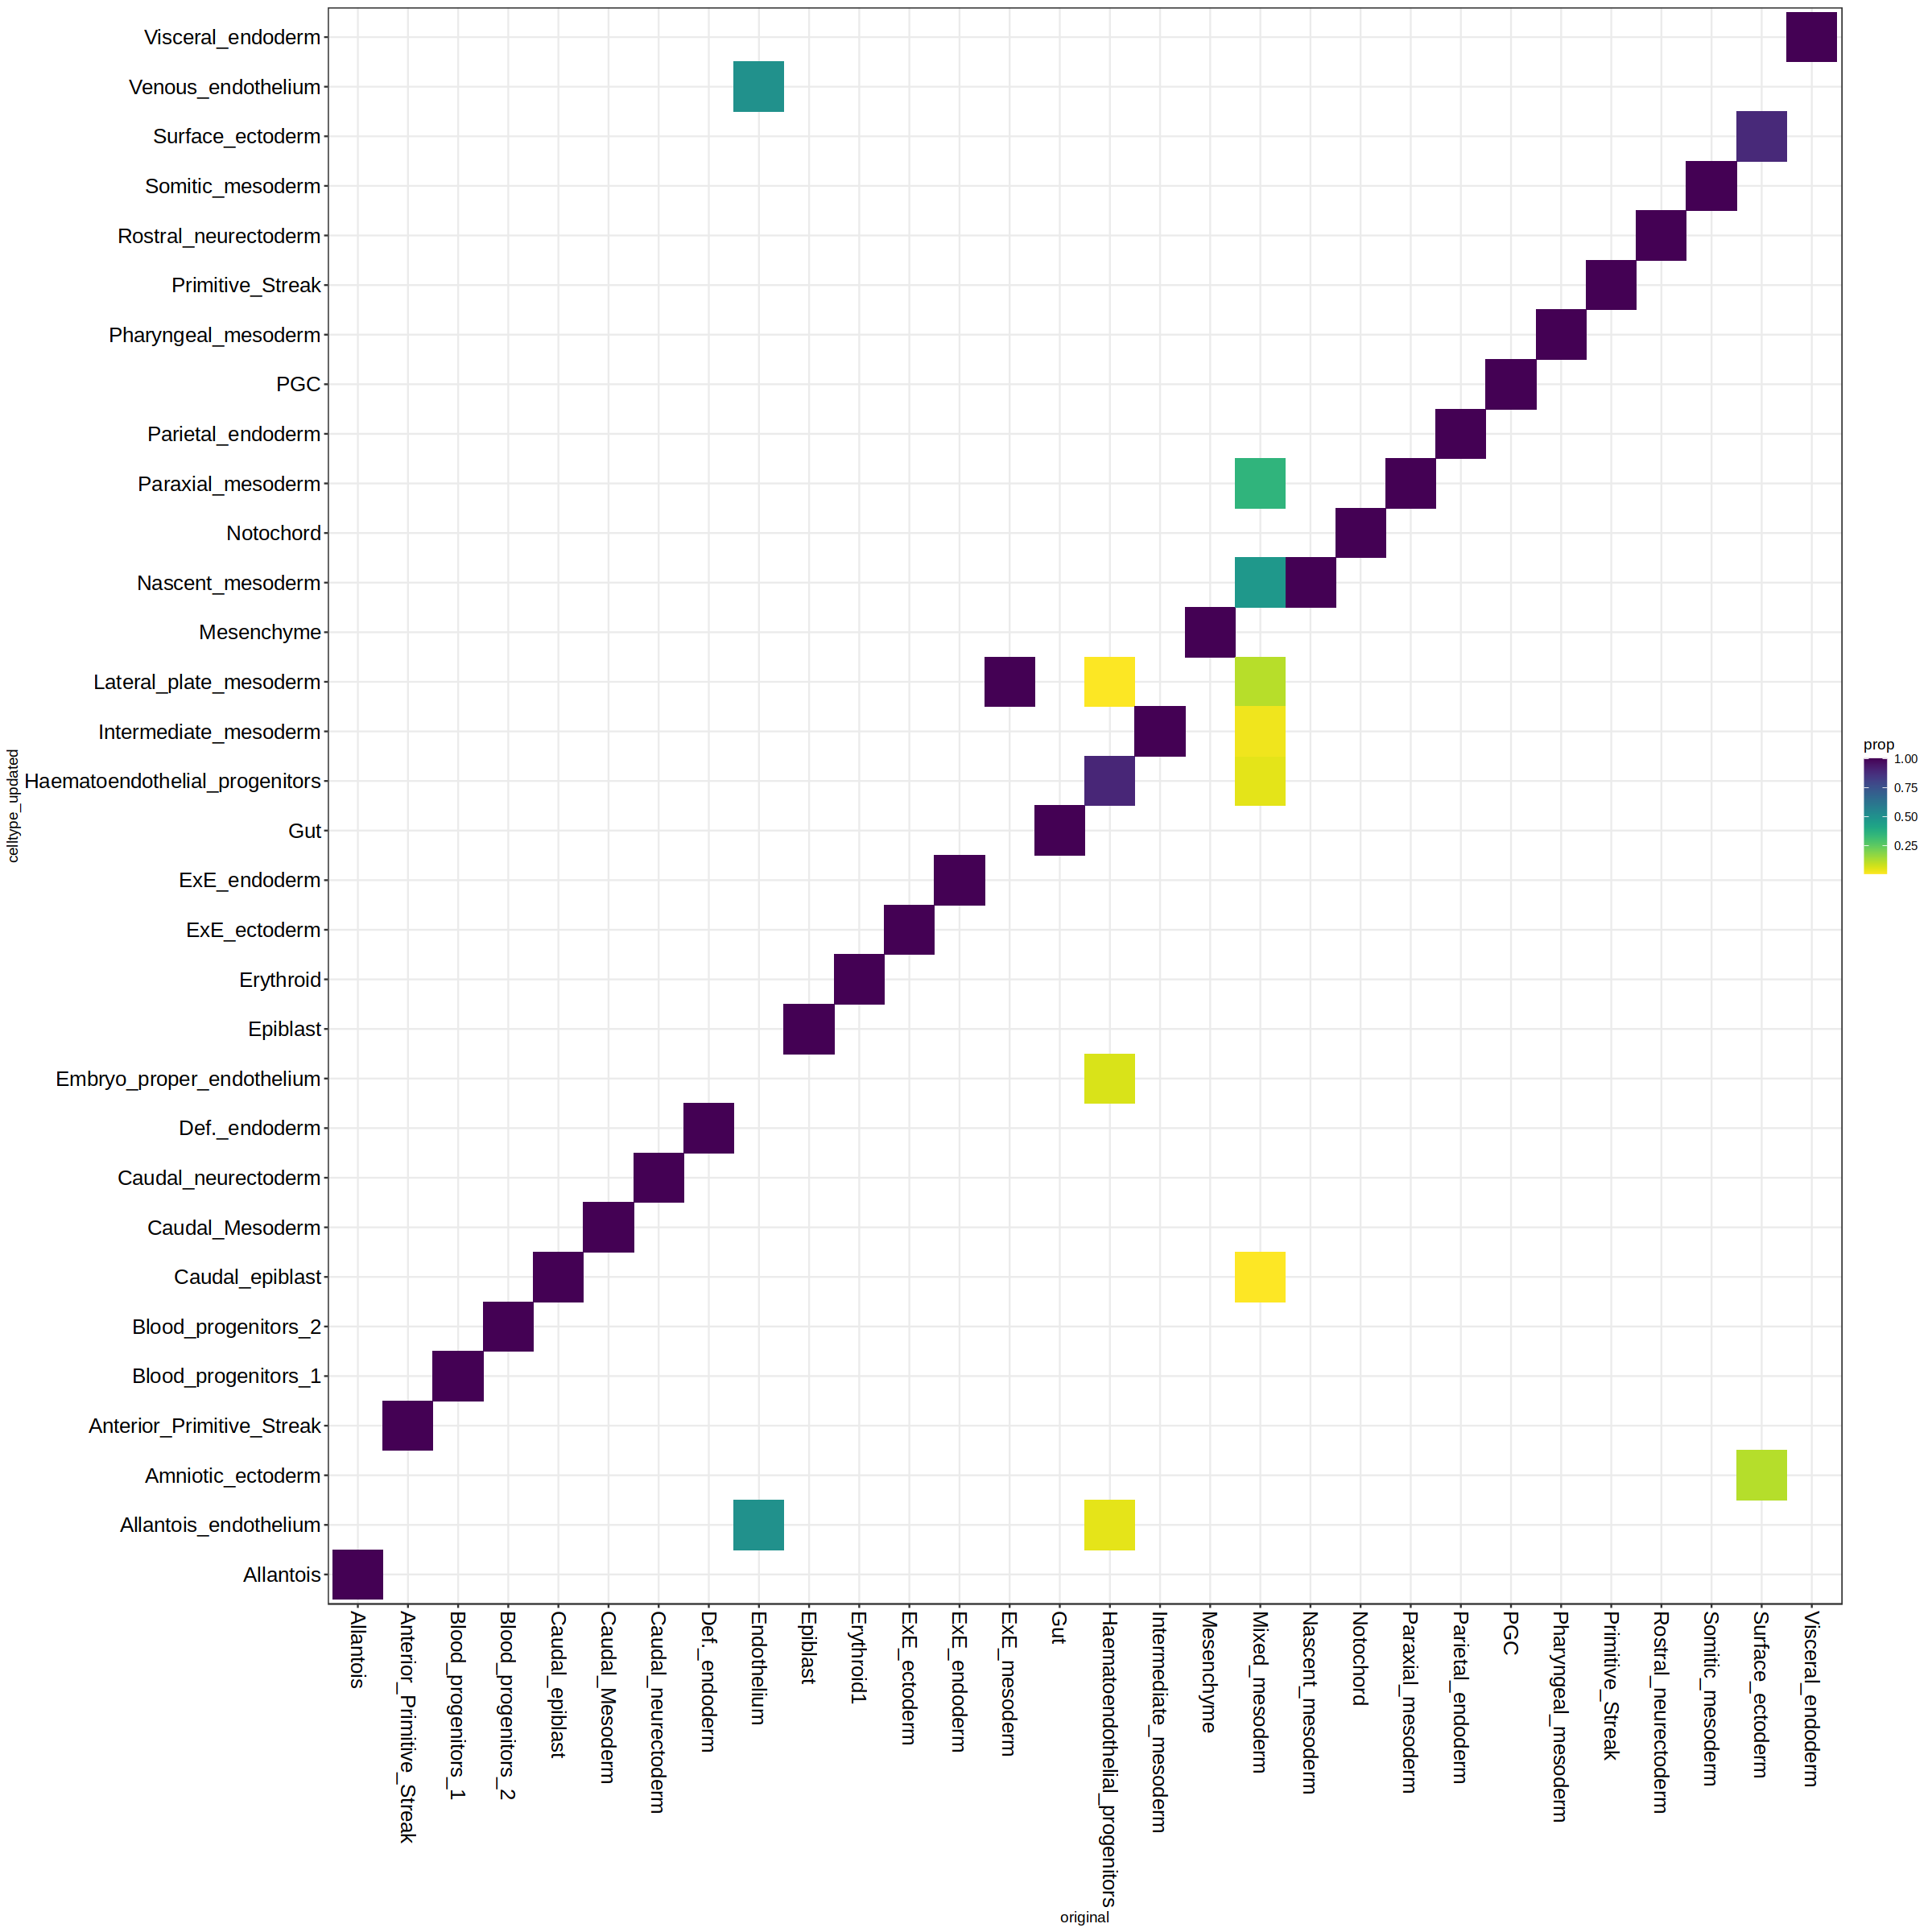

In [7]:
compare = data.table(cell = meta$cell, original = meta$celltype.mapped_mnn, celltype_updated = meta$celltype_updated) %>%
    .[,count := .N, by=c('original', 'celltype_updated')] %>%
    .[,tot := .N, by='original'] %>% .[,prop := count/tot] %>%
    unique(by=c('original', 'celltype_updated')) 

options(repr.plot.width=20, repr.plot.height=20)
ggplot(compare[!is.na(original)], aes(original, celltype_updated, fill=prop)) + 
    geom_tile() + 
    viridis::scale_fill_viridis(begin=1, end=0) + 
    theme_bw() + 
    theme(axis.text.x = element_text(angle=-90, hjust=0, vjust=0.5),
          axis.text = element_text(color='black', size=15))

In [8]:
# Load cell metadata
args = list()
args$atlas_metadata = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation/pijuansala2019_gastrulation10x/sample_metadata_extended.txt.gz'
meta_atlas <- fread(args$atlas_metadata)

In [9]:
meta = merge(meta, meta_atlas[,c('cell', 'umapX','umapY')], by.x='closest.cell_mnn', by.y='cell')

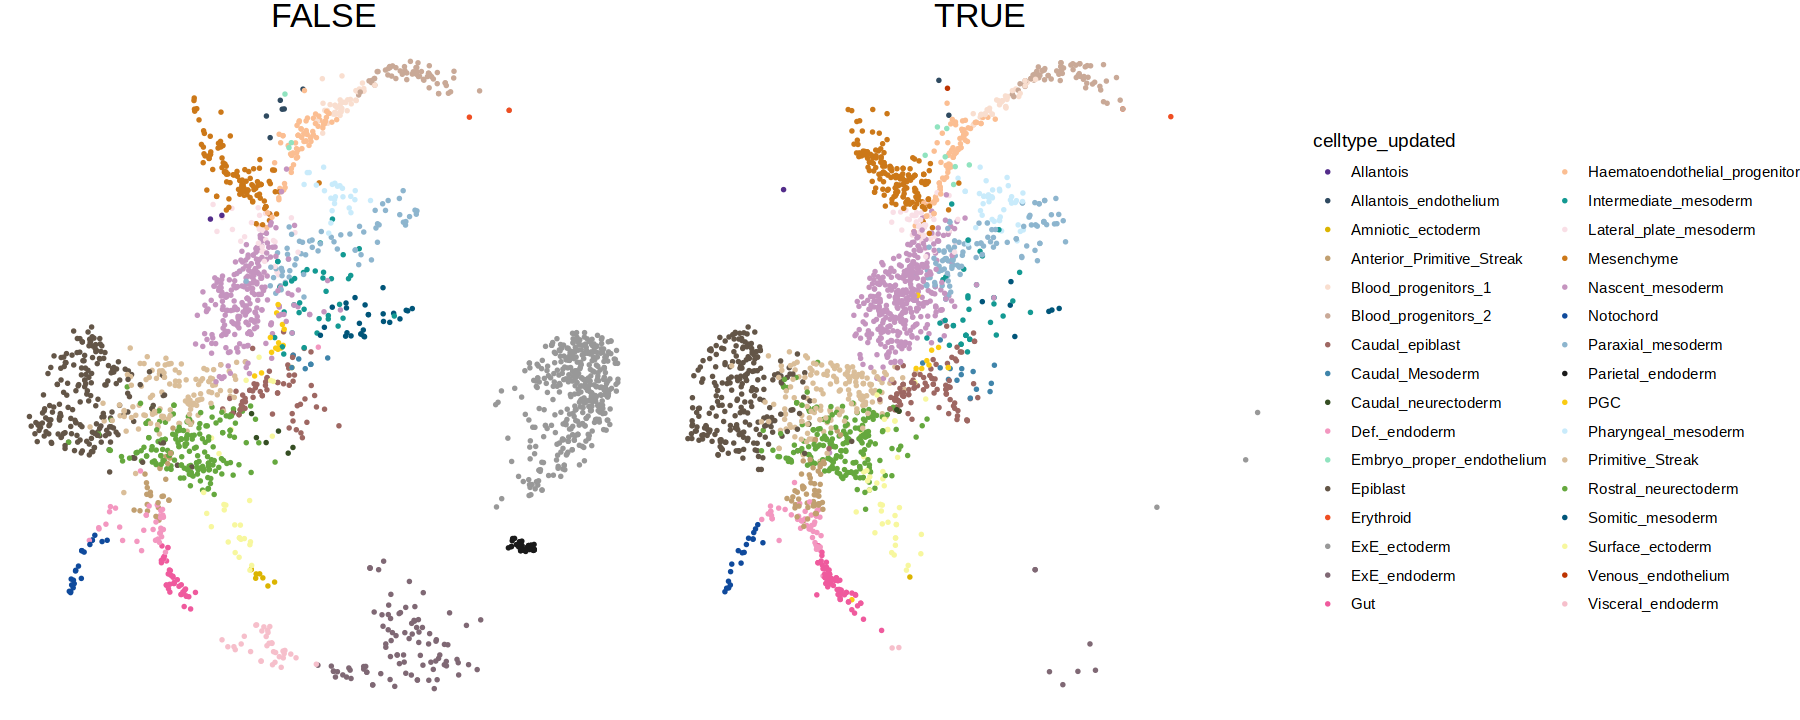

In [10]:
options(repr.plot.width=15, repr.plot.height=6)
ggplot(meta, aes(umapX, umapY, color=celltype_updated)) + 
    geom_point(size=0.5) + 
    scale_color_manual(values=c(opts$celltype.colors, opts$celltype_extended.colors)) + 
    facet_wrap(~tdTom) + 
    theme_void() + 
    theme(legend.position='right',
          strip.background=element_blank(),
          strip.text=element_text(size=20))

In [11]:
fwrite(meta, paste0(io$basedir, '/results/rna/mapping/manual/metadata_mapping_updated.txt.gz'))

In [12]:
p = ggplot(meta, aes(umapX, umapY, color=celltype_updated)) + 
    geom_point(data = rbind(meta_atlas %>% copy() %>% .[,tdTom:=FALSE], meta_atlas %>% copy() %>% .[,tdTom:=TRUE]), 
               color='grey90') + 
    scale_color_manual(values=c(opts$celltype.colors, opts$celltype_extended.colors)) + 
    geom_point(size=0.5) + 
    facet_wrap(~tdTom) + 
    theme_void() + 
    theme(legend.position='right',
          strip.background=element_blank(),
          strip.text=element_text(size=20))

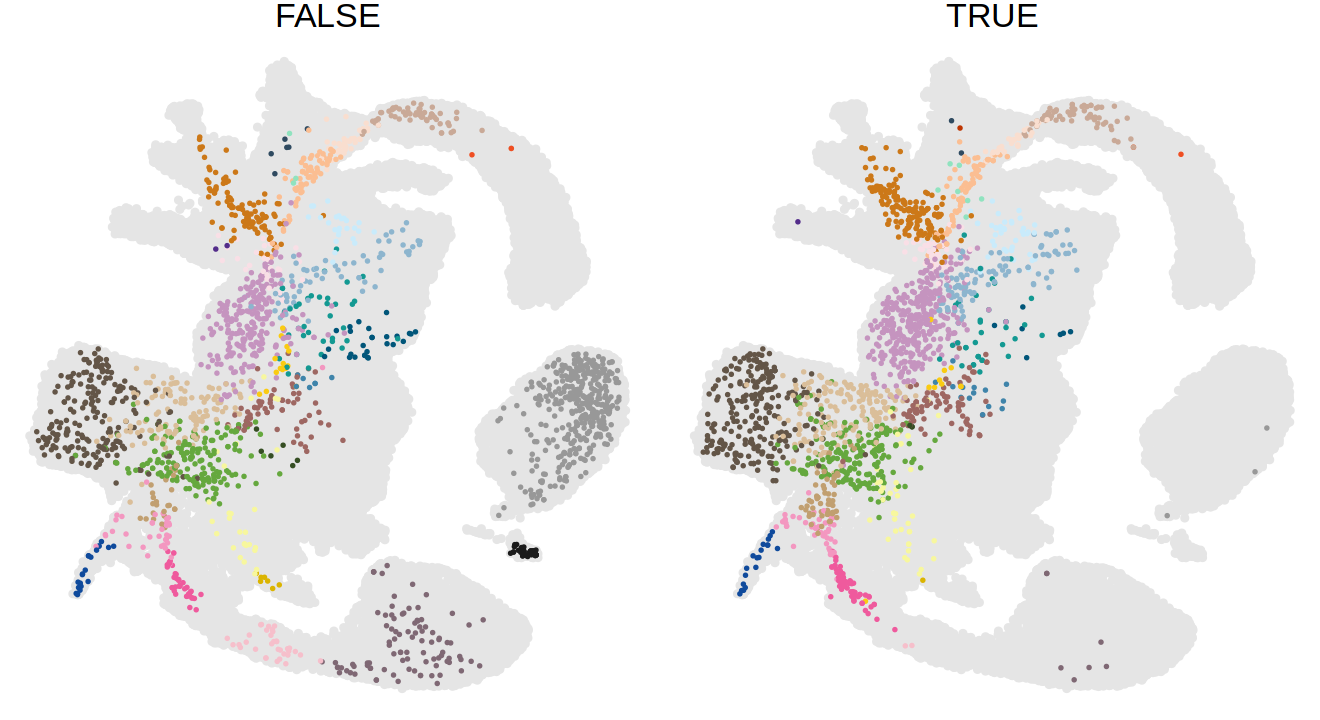

In [13]:
options(repr.plot.width=11)
p + theme(legend.position = 'none')

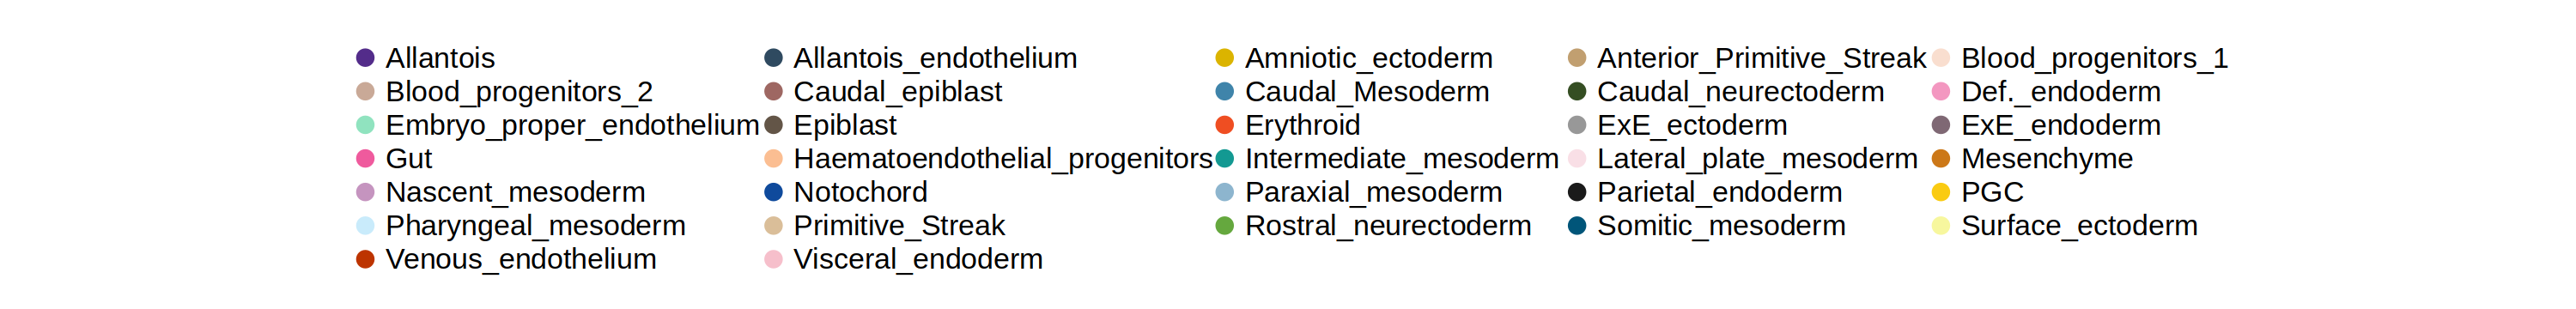

In [14]:
options(repr.plot.width=25, repr.plot.height=3)
celltype_legend = as_ggplot(get_legend(ggplot(meta, aes(umapX, umapY, color=celltype_updated)) +
                geom_point(size=5) + 
                scale_color_manual(values=c(opts$celltype.colors, opts$celltype_extended.colors)) + 
                guides(color=guide_legend(nrow=7, byrow=TRUE)) +
                theme_void() + 
                theme(legend.text = element_text(size=20),
                      legend.title = element_blank())))
celltype_legend

### Celltype proportions

In [15]:
celltype2germlayer = c(
    'Amniotic_ectoderm' = 'ectoderm', 
    'Surface_ectoderm' = 'ectoderm', 
    'Caudal_neurectoderm' = 'ectoderm',
    'Rostral_neurectoderm' = 'ectoderm', 
    'Spinal_cord' = 'ectoderm', 
    'NMP' = 'ectoderm', 
    'Forebrain_Midbrain_Hindbrain' = 'ectoderm', 
    'Neural_crest' = 'ectoderm', 

    'Notochord' = 'endoderm', 
    'Def._endoderm' = 'endoderm', 
    'Gut' = 'endoderm', 

    'PGC' = 'other', 
    'Caudal_epiblast' = 'other', 
    'Mixed' = 'other', 

    'Intermediate_mesoderm' = 'mesoderm', 
    'Nascent_mesoderm' = 'mesoderm', 
    'Lateral_plate_mesoderm' = 'mesoderm', 
    'Allantois' = 'mesoderm', 
    'Somitic_mesoderm' = 'mesoderm', 
    'Caudal_Mesoderm' = 'mesoderm', 
    'Mesenchyme' = 'mesoderm', 
    'Pharyngeal_mesoderm' = 'mesoderm', 
    'Paraxial_mesoderm' = 'mesoderm', 
    'Cardiomyocytes' = 'mesoderm', 
    'Venous_endothelium' = 'mesoderm', 
    'Embryo_proper_endothelium' = 'mesoderm', 
    'Allantois_endothelium' = 'mesoderm', 
    'YS_endothelium' = 'mesoderm', 
    'Blood_progenitors_1' = 'mesoderm', 
    'Blood_progenitors_2' = 'mesoderm',
    'Erythroid' = 'mesoderm'
)

In [16]:
meta = fread('/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/results/rna/mapping/manual/metadata_mapping_updated.txt.gz')%>%
    .[!celltype_updated%in%c("Visceral_endoderm","ExE_endoderm","ExE_ectoderm","Parietal_endoderm")] %>%
    .[,pool:=stringr::str_replace_all(sample,opts$sample2pool)]

In [17]:
tmp = meta %>% copy() %>% 
    .[,tot := .N, by = 'sample'] %>% 
    .[,prop := .N/tot, by = c('sample', 'celltype_updated')] %>% 
    unique(by = c('sample', 'celltype_updated'))

all = merge(as.data.table(expand.grid(unique(tmp$sample), unique(tmp$celltype_updated))) %>% 
                        setnames(c('sample', 'celltype_updated')),
          tmp %>% copy() %>% .[,c('sample', 'tdTom', 'pool')] %>% unique(by='sample'), by = 'sample'
           )

tmp = merge(tmp, all, by=c('sample', 'celltype_updated', 'tdTom', 'pool'), all = TRUE) %>% 
        replace(., is.na(.), 0)

In [20]:
# Calculate differential abundance statistics
tmp = meta %>% copy() %>% 
    .[,tot := .N, by = 'sample'] %>% 
    .[,prop := .N/tot, by = c('sample', 'celltype_updated')] %>% 
    unique(by = c('sample', 'celltype_updated'))

all = merge(as.data.table(expand.grid(unique(tmp$sample), unique(tmp$celltype_updated))) %>% 
                        setnames(c('sample', 'celltype_updated')),
          tmp %>% copy() %>% .[,c('sample', 'tdTom', 'pool')] %>% unique(by='sample'), by = 'sample'
           )

tmp = merge(tmp, all, by=c('sample', 'celltype_updated', 'tdTom', 'pool'), all = TRUE) %>% 
         replace(., is.na(.), 0)
        #replace(., is.na(.), 1e-3)

tmp2 = merge(tmp %>% copy() %>%
                .[tdTom == TRUE] %>% 
                .[,c('pool', 'celltype_updated', 'prop')] %>% setnames('prop', 'KO'),
             tmp %>% copy() %>%
                .[tdTom == FALSE] %>% 
                .[,c('pool', 'celltype_updated', 'prop')] %>% setnames('prop', 'WT'),
             by = c('pool', 'celltype_updated'), keep.all=TRUE
             ) %>% 
     .[,log2fc := log2((KO+1e-5)/(WT+1e-5))] %>% 
    #.[,fc := (KO)/(WT)] %>% 
    .[KO>0 | WT > 0] # remove pools where both are 0

stats = lapply(unique(tmp2$celltype_updated), function(x){
    tmp3 = tmp2 %>% copy() %>% 
            .[celltype_updated == x]
    if(nrow(tmp3) > 1){
        tmp4 = data.table(celltype_updated = x,
                          avg_log2fc = mean(tmp3$log2fc),
                          sd_log2fc = sd(tmp3$log2fc),
                          #p_value = t.test(tmp3$KO, tmp3$WT, paired=TRUE, alternative = "two.sided")$p.value,
                          p_value = t.test(tmp3$log2fc)$p.value,
                          #p_value = t.test(tmp3$fc, mu=1)$p.value,
                          samples = nrow(tmp3))
    } else{
        tmp4 = data.table(celltype_updated = x,
                  avg_log2fc = mean(tmp3$log2fc),
                  sd_log2fc = NA,
                  p_value = NA,
                  samples = 1)
    }
    return(tmp4)
}) %>% rbindlist() %>% 
    .[,FDR := p.adjust(p_value, n=nrow(.), method='fdr')] %>% 
    .[,germ_layer := celltype2germlayer[as.character(celltype_updated)]] %>% 
    .[,sig := ifelse(FDR <= 0.05, TRUE, FALSE)]


ERROR: Error in p.adjust(p_value, n = nrow(.), method = "fdr"): object 'p_value' not found


In [19]:
options(repr.plot.width=15, repr.plot.height = 8)
ggplot(stats[order(avg_log2fc)][,celltype_updated := factor(celltype_updated, levels = unique(celltype_updated))], 
           aes(celltype_updated, avg_log2fc, fill = celltype_updated, color=sig)) + 
    geom_bar(stat='identity', linewidth=0.7) + 
    geom_errorbar(aes(ymin=avg_log2fc-sd_log2fc, ymax=avg_log2fc+sd_log2fc), width=.2, color='black') + 
    scale_fill_manual(values=c(opts$celltype.colors, opts$celltype_extended.colors)) + 
    scale_color_manual(values=c('TRUE' = 'red', 'FALSE' = 'black')) + 
    facet_grid(cols = vars(germ_layer), scales='free', space='free') + 
    geom_hline(yintercept=0) + 
    theme_bw() + 
        theme(legend.position = 'none', 
            axis.text = element_text(size=15, color='black'),
                          axis.text.x = element_text(size=15, color='black', angle=-90, hjust=0, vjust=0.5),

              axis.title = element_text(size=20, color='black'),
              axis.title.x = element_blank(), 
              legend.text = element_text(size=15),
              legend.title = element_text(size=20),
              plot.title = element_text(size=25),
              panel.border = element_rect(color='black', linewidth=1.3),
                       strip.background=element_blank(),
          strip.text.x = element_blank())

ERROR: Error in ggplot(stats[order(avg_log2fc)][, `:=`(celltype_updated, factor(celltype_updated, : object 'stats' not found
